In [1]:
!pip install transformers==4.52.4

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 40.5 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 26.4 MB/s eta 0:00:0000:0100:01
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.22.1
    Uninstalling tokenizers-0.22.1:
      Successfully uninstalled tokenizers-0.22.1
  Attempting uninstall: transformers
    Found existing installation: transformers 4.57.1
    Uninstalling transformers-4.57.1:
      Successfully uninstalled transformers-4.57.1


In [2]:
!pip -q install "transformers>=4.43" "accelerate>=0.33" "bitsandbytes>=0.43" "autoawq>=0.2.7" torch --extra-index-url https://download.pytorch.org/whl/cu121

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.3/74.3 kB 1.8 MB/s eta 0:00:00a 0:00:01
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 MB 30.0 MB/s eta 0:00:00:00:0100:01


In [3]:
!pip install -U langchain langchain-core langchain-community

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.8/108.8 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 490.2/490.2 kB 12.9 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 55.1 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 45.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 157.4/157.4 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 342.0/342.0 kB 22.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.3/46.3 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.0/67.0 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.6/212.6 kB 14.0 MB/s eta 0:00:00
  Attempting uninstall: packaging
    Found existing installation: packaging 26.0rc2
    Uninstalling packaging-26.0rc2:
      Successfully uninstalled packaging-26.0rc2
  Attempting uninstall: lang

In [4]:
from IPython.display import display
import ipywidgets as widgets

upload = widgets.FileUpload(
    accept='.csv,.xlsx,.txt',
    multiple=False
)

display(upload)


FileUpload(value=(), accept='.csv,.xlsx,.txt', description='Upload')

In [5]:
import pandas as pd
import chardet
from io import BytesIO

def load_uploaded_file(uploaded_file):
    if len(uploaded_file.value) == 0:
        raise ValueError("No file uploaded")

    file_info = uploaded_file.value[0]
    file_name = file_info['name']
    content = bytes(file_info['content'])   

    print(f"Loaded file: {file_name}")

    if file_name.endswith('.csv'):
        encoding = chardet.detect(content)['encoding']
        df = pd.read_csv(BytesIO(content), encoding=encoding)

    elif file_name.endswith('.xlsx'):
        df = pd.read_excel(BytesIO(content))

    elif file_name.endswith('.txt'):
        text = content.decode("utf-8", errors="ignore")
        lines = [line for line in text.splitlines() if line.strip()]
        df = pd.DataFrame(lines, columns=["review_text"])

    else:
        raise ValueError("Unsupported file type")

    return df

In [7]:
df = load_uploaded_file(upload)
df.head()

Loaded file: TestReviews.csv


,review_text,class
0,Fantastic spot for an even or a quite cocktail...,1
1,"Love, love, love the calamari. It's so good an...",1
2,"Love this place. Stiff martinis and cocktails,...",1
3,It's everything a great cocktail bar should be...,1
4,"I came here before a pirates game, so it was a...",1


In [8]:
import re
import nltk
from nltk.corpus import stopwords

nltk.download("stopwords")
stop_words = set(stopwords.words("english"))
def clean_text(text):
    text = str(text).lower()                         
    text = re.sub(r"http\S+", "", text)              
    text = re.sub(r"[^a-z\s]", "", text)             
    text = re.sub(r"\s+", " ", text).strip()         
    text = " ".join(
        word for word in text.split()
        if word not in stop_words
    )
    return text

df["clean_text"] = df["review_text"].apply(clean_text)
df.head()

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,review_text,class,clean_text
0,Fantastic spot for an even or a quite cocktail...,1,fantastic spot even quite cocktail swell host ...
1,"Love, love, love the calamari. It's so good an...",1,love love love calamari good spicy endless lis...
2,"Love this place. Stiff martinis and cocktails,...",1,love place stiff martinis cocktails cheap drin...
3,It's everything a great cocktail bar should be...,1,everything great cocktail bar great location a...
4,"I came here before a pirates game, so it was a...",1,came pirates game around ish evening gotten lu...


In [20]:
import torch
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    pipeline
)

model_id = "nlptown/bert-base-multilingual-uncased-sentiment"

tokenizer = AutoTokenizer.from_pretrained(model_id)

model = AutoModelForSequenceClassification.from_pretrained(
    model_id,
    torch_dtype=torch.float16
).to("cuda")

model.eval()
torch.set_grad_enabled(False)

sentiment_analyzer = pipeline(
    "sentiment-analysis",
    model=model,
    tokenizer=tokenizer,
    device=0   
)

print("Sentiment model loaded on GPU (FP16)")

2026-02-01 00:56:50.786628: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1769907411.248574      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1769907411.374993      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1769907412.537325      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769907412.537373      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769907412.537376      55 computation_placer.cc:177] computation placer alr

tokenizer_config.json:   0%|          | 0.00/39.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/953 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/669M [00:00<?, ?B/s]

Device set to use cuda:0


Sentiment model loaded on GPU (FP16)


In [10]:
from tqdm import tqdm

texts = df["clean_text"].astype(str).tolist()

def batched_sentiment_analysis(
    texts,
    batch_size=128,   
    max_length=256
):
    results = []

    for i in tqdm(range(0, len(texts), batch_size)):
        batch = texts[i:i + batch_size]

        outputs = sentiment_analyzer(
            batch,
            truncation=True,
            max_length=max_length
        )

        results.extend(outputs)

    return results

sentiment_results = batched_sentiment_analysis(
    texts,
    batch_size=128,
    max_length=256
)

df["sentiment_raw"] = [res["label"] for res in sentiment_results]
df["sentiment_score"] = [float(res["score"]) for res in sentiment_results]

print("Sentiment inference completed on GPU")
df.head()


100%|██████████| 34/34 [00:39<00:00,  1.17s/it]

Sentiment inference completed on GPU


,review_text,class,clean_text,sentiment_raw,sentiment_score
0,Fantastic spot for an even or a quite cocktail...,1,fantastic spot even quite cocktail swell host ...,5 stars,0.801794
1,"Love, love, love the calamari. It's so good an...",1,love love love calamari good spicy endless lis...,5 stars,0.613174
2,"Love this place. Stiff martinis and cocktails,...",1,love place stiff martinis cocktails cheap drin...,4 stars,0.442320
3,It's everything a great cocktail bar should be...,1,everything great cocktail bar great location a...,4 stars,0.640283
4,"I came here before a pirates game, so it was a...",1,came pirates game around ish evening gotten lu...,5 stars,0.572287


In [11]:
def map_sentiment(label):
    stars = int(label.split()[0])

    if stars <= 2:
        return "NEGATIVE"
    elif stars == 3:
        return "NEUTRAL"
    else:
        return "POSITIVE"

df["sentiment"] = df["sentiment_raw"].apply(map_sentiment)
df.head(50)

,review_text,class,clean_text,sentiment_raw,sentiment_score,sentiment
0,Fantastic spot for an even or a quite cocktail...,1,fantastic spot even quite cocktail swell host ...,5 stars,0.801794,POSITIVE
1,"Love, love, love the calamari. It's so good an...",1,love love love calamari good spicy endless lis...,5 stars,0.613174,POSITIVE
2,"Love this place. Stiff martinis and cocktails,...",1,love place stiff martinis cocktails cheap drin...,4 stars,0.442320,POSITIVE
3,It's everything a great cocktail bar should be...,1,everything great cocktail bar great location a...,4 stars,0.640283,POSITIVE
4,"I came here before a pirates game, so it was a...",1,came pirates game around ish evening gotten lu...,5 stars,0.572287,POSITIVE
5,Olive or Twist is the historic site of my VERY...,1,olive twist historic site first martini turned...,5 stars,0.325136,POSITIVE
6,"A beautiful little bar with an exciting ""marti...",1,beautiful little bar exciting martini list ste...,5 stars,0.684529,POSITIVE
7,My favorite bar in town love the live music an...,1,favorite bar town love live music martinis fav...,5 stars,0.779670,POSITIVE
8,"The location is in a strip mall, but this plac...",1,location strip mall place diamond rough food b...,5 stars,0.448173,POSITIVE
9,THIS PLACE IS OPEN!The best food and the best ...,1,place openthe best food best service try butte...,5 stars,0.891023,POSITIVE


In [12]:
df.to_csv("final_output.csv", index=False, encoding="utf-8")

In [13]:
sentiment_counts = df["sentiment"].value_counts()
sentiment_counts

sentiment
POSITIVE    2424
NEGATIVE    1716
NEUTRAL      181
Name: count, dtype: int64

In [14]:
sentiment_percentages = (
    sentiment_counts / sentiment_counts.sum() * 100
).round(2)
sentiment_summary = pd.DataFrame({
    "Sentiment": sentiment_counts.index,
    "Count": sentiment_counts.values,
    "Percentage (%)": sentiment_percentages.values
})

sentiment_summary


,Sentiment,Count,Percentage (%)
0,POSITIVE,2424,56.10
1,NEGATIVE,1716,39.71
2,NEUTRAL,181,4.19


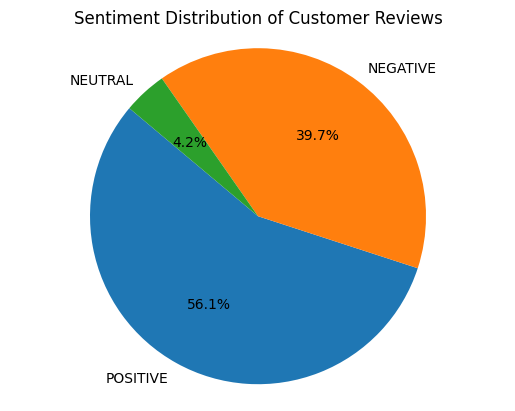

In [15]:
import matplotlib.pyplot as plt

plt.figure()
plt.pie(
    sentiment_summary["Percentage (%)"],
    labels=sentiment_summary["Sentiment"],
    autopct="%1.1f%%",
    startangle=140
)
plt.title("Sentiment Distribution of Customer Reviews")
plt.axis("equal")  
plt.show()


In [35]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, pipeline

MODEL_NAME = "google/flan-t5-base"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

model = AutoModelForSeq2SeqLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16
).to("cuda")

model.eval()
torch.set_grad_enabled(False)

hf_pipeline = pipeline(
    "text2text-generation",
    model=model,
    tokenizer=tokenizer,
    device=0,
    batch_size=64
)

_ = hf_pipeline("Extract main issue: bad service")

print("FLAN-T5 loaded")

Device set to use cuda:0


FLAN-T5 loaded


In [48]:
from tqdm import tqdm

def build_prompt(text):
    text = " ".join(str(text).split()[:200])

    return f"""
You are extracting customer issues from reviews.

Rules:
- Identify the MAIN problem.
- Return ONLY a short issue name (noun phrase).
- Use 2 to 4 words only.
- Describe a PROBLEM, not an opinion.
- Do NOT return a sentence.
- Do NOT include advice or emotions.
- Do NOT use: I, we, you, they.

Good:
- poor service
- rude staff
- long wait time
- technical issue
- payment problem

Bad:
- I don't think I'll return
- Don't waste your money
- The service was terrible

Review:
{text}

Issue:
"""




def extract_issues_batch(texts, batch_size=64):
    issues = []

    for i in tqdm(
        range(0, len(texts), batch_size),
        desc="Extracting issues"
    ):
        batch = texts[i:i + batch_size]
        prompts = [build_prompt(t) for t in batch]

        outputs = hf_pipeline(
            prompts,
            max_new_tokens=8,
            do_sample=False
        )

        for out in outputs:
            issue = out["generated_text"].lower().strip()
            issue = issue.split("\n")[0]
            issue = issue.replace(".", "")
            issue = " ".join(issue.split()[:4])
            issues.append(issue)

    return issues


def is_valid_issue_phrase(issue):
    if not issue:
        return False

    pronouns = [" i ", " i'm", " i'", " we ", " they ", " you "]
    if any(p in f" {issue} " for p in pronouns):
        return False

    verbs = [
        "think", "feel", "believe", "know",
        "like", "love", "hate", "tried"
    ]
    if any(v in issue for v in verbs):
        return False

    if issue.startswith("bad:"):
        return False

    if len(issue.split()) < 2:
        return False

    return True



In [43]:
import os
import logging

os.environ["TRANSFORMERS_VERBOSITY"] = "error"
logging.getLogger("transformers").setLevel(logging.ERROR)

In [49]:
neg_df = df[df["sentiment"] == "NEGATIVE"].copy()

issues_raw = extract_issues_batch(
    neg_df["review_text"].astype(str).tolist(),
    batch_size=64
)

neg_df["issue_raw"] = issues_raw

neg_df["issue"] = neg_df["issue_raw"].apply(
    lambda x: x if is_valid_issue_phrase(x) else "other issue"
)

df.loc[neg_df.index, "issue"] = neg_df["issue"]

neg_df.shape


Extracting issues: 100%|██████████| 27/27 [01:00<00:00,  2.25s/it]


(1716, 8)

In [55]:
def normalize_issue(issue, review):
    text = f"{issue} {review}".lower()

    service_words = [
        "service", "experience", "support",
        "unprofessional", "professional", "help"
    ]

    staff_words = [
        "staff", "employee", "worker",
        "manager", "owner", "cashier"
    ]

    wait_words = [
        "wait", "waiting", "delay",
        "late", "minutes", "slow"
    ]

    price_words = [
        "price", "expensive", "cost",
        "overpriced", "ripoff", "charge"
    ]

    quality_words = [
        "food", "quality", "dirty",
        "smell", "cold", "taste",
        "stale", "burnt"
    ]

    management_words = [
        "management", "policy", "rules"
    ]

    if any(w in text for w in service_words):
        return "poor service"
    if any(w in text for w in staff_words):
        return "rude staff"
    if any(w in text for w in wait_words):
        return "long wait time"
    if any(w in text for w in price_words):
        return "overpriced"
    if any(w in text for w in quality_words):
        return "bad product quality"
    if any(w in text for w in management_words):
        return "bad management"

    return "other issue"
neg_df["issue_norm"] = neg_df.apply(
    lambda r: normalize_issue(r["issue"], r["review_text"]),
    axis=1
)
issue_counts = (
    neg_df["issue_norm"]
    .value_counts()
    .reset_index()
)

issue_counts.columns = ["issue", "count"]
issue_counts


,issue,count
0,poor service,763
1,other issue,278
2,rude staff,223
3,long wait time,200
4,overpriced,129
5,bad product quality,115
6,bad management,8


In [56]:
issue_counts["count"].sum()

np.int64(1716)

In [58]:
def severity_label(count):
    if count >= 400:
        return "Critical"
    elif count >= 200:
        return "High"
    elif count >= 80:
        return "Medium"
    else:
        return "Low"

issue_counts["severity"] = issue_counts["count"].apply(severity_label)

output = issue_counts.sort_values("count", ascending=False)
output


,issue,count,severity
0,poor service,763,Critical
1,other issue,278,High
2,rude staff,223,High
3,long wait time,200,High
4,overpriced,129,Medium
5,bad product quality,115,Medium
6,bad management,8,Low


In [66]:
import json

json_output = {
    "summary": {
        "total_reviews": int(sentiment_counts.sum()),
        "sentiment_breakdown": [
            {
                "sentiment": row["Sentiment"],
                "count": int(row["Count"]),
                "percentage": float(row["Percentage (%)"])
            }
            for _, row in sentiment_summary.iterrows()
        ]
    },
    "issue_analysis": {
        "total_negative_reviews": int(output["count"].sum()),
        "total_issue_categories": int(len(output)),
        "issues": [
            {
                "issue": row["issue"],
                "count": int(row["count"]),
                "severity": row["severity"]
            }
            for _, row in output.iterrows()
        ]
    }
}

print(json.dumps(json_output, indent=2))


{
  "summary": {
    "total_reviews": 4321,
    "sentiment_breakdown": [
      {
        "sentiment": "POSITIVE",
        "count": 2424,
        "percentage": 56.1
      },
      {
        "sentiment": "NEGATIVE",
        "count": 1716,
        "percentage": 39.71
      },
      {
        "sentiment": "NEUTRAL",
        "count": 181,
        "percentage": 4.19
      }
    ]
  },
  "issue_analysis": {
    "total_negative_reviews": 1716,
    "total_issue_categories": 7,
    "issues": [
      {
        "issue": "poor service",
        "count": 763,
        "severity": "Critical"
      },
      {
        "issue": "other issue",
        "count": 278,
        "severity": "High"
      },
      {
        "issue": "rude staff",
        "count": 223,
        "severity": "High"
      },
      {
        "issue": "long wait time",
        "count": 200,
        "severity": "High"
      },
      {
        "issue": "overpriced",
        "count": 129,
        "severity": "Medium"
      },
      {
     

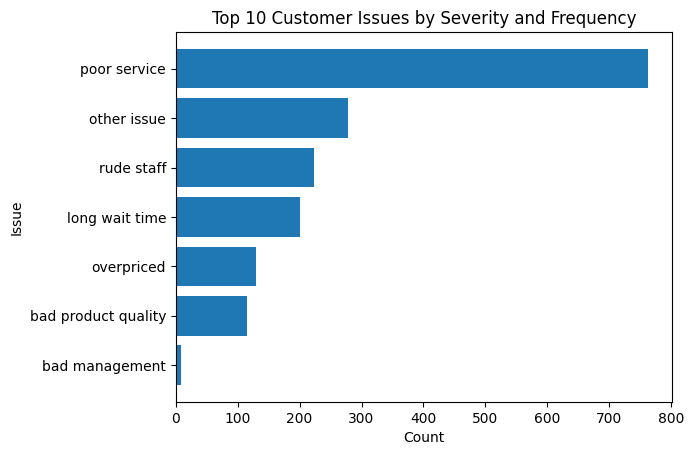

In [59]:
import matplotlib.pyplot as plt

severity_order = {"Critical": 3, "High": 2, "Medium": 1, "Low": 0}

vis_df = output.copy()
vis_df["severity_rank"] = vis_df["severity"].map(severity_order)

top_issues = (
    vis_df
    .sort_values(["severity_rank", "count"], ascending=False)
    .head(10)
)

plt.figure()
plt.barh(top_issues["issue"], top_issues["count"])
plt.xlabel("Count")
plt.ylabel("Issue")
plt.title("Top 10 Customer Issues by Severity and Frequency")
plt.gca().invert_yaxis()
plt.show()


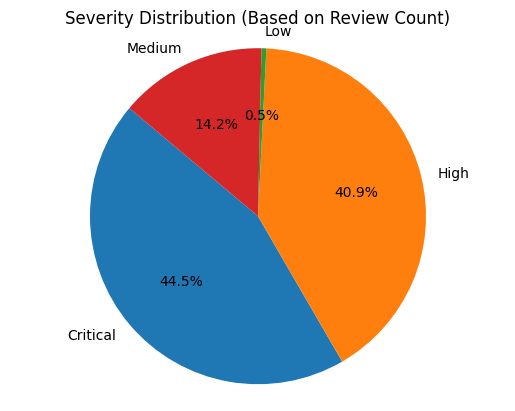

In [63]:
severity_weighted = (
    output.groupby("severity")["count"]
    .sum()
)

plt.figure()
plt.pie(
    severity_weighted.values,
    labels=severity_weighted.index,
    autopct="%1.1f%%",
    startangle=140
)
plt.title("Severity Distribution (Based on Review Count)")
plt.axis("equal")
plt.show()


In [1]:
!pip install fastapi uvicorn pandas python-multipart pyngrok

In [2]:
from pyngrok import ngrok

ngrok.set_auth_token("38zKVEeqUIvSUpsh7pS1MXH9Zfg_2tydCBgqoqSJ9QfiscLYc")


In [3]:
from pyngrok import ngrok
from fastapi import FastAPI, UploadFile, File
from io import BytesIO
import pandas as pd
import threading
import uvicorn
import torch
import re
import nltk
from nltk.corpus import stopwords
from transformers import AutoTokenizer, AutoModelForSequenceClassification, AutoModelForSeq2SeqLM, pipeline
import time

print("GPU count:", torch.cuda.device_count())

nltk.download("stopwords")
stop_words = set(stopwords.words("english"))

def clean_text(text):
    text = str(text)[:1000]
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    text = " ".join(word for word in text.split() if word not in stop_words)
    return text

def map_sentiment(label):
    stars = int(label.split()[0])
    if stars <= 2:
        return "NEGATIVE"
    elif stars == 3:
        return "NEUTRAL"
    else:
        return "POSITIVE"

def severity_label(count):
    if count >= 400:
        return "Critical"
    elif count >= 200:
        return "High"
    elif count >= 80:
        return "Medium"
    else:
        return "Low"


2026-02-17 15:59:04.433875: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771343944.578469      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771343944.620141      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1771343944.954610      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771343944.954675      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771343944.954678      55 computation_placer.cc:177] computation placer alr

GPU count: 2


[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [4]:
# ======================
# Sentiment → GPU 0
# ======================
model_id = "nlptown/bert-base-multilingual-uncased-sentiment"

tokenizer_sent = AutoTokenizer.from_pretrained(model_id)

model_sent = AutoModelForSequenceClassification.from_pretrained(
    model_id,
    torch_dtype=torch.float16
).to("cuda:0")

sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model=model_sent,
    tokenizer=tokenizer_sent,
    device=0
)

# ======================
# Issue Model → GPU 1
# ======================
MODEL_NAME = "google/flan-t5-base"

tokenizer_issue = AutoTokenizer.from_pretrained(MODEL_NAME)

model_issue = AutoModelForSeq2SeqLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16
).to("cuda:1")

issue_pipeline = pipeline(
    "text2text-generation",
    model=model_issue,
    tokenizer=tokenizer_issue,
    device=1,
    batch_size=16
)

print("Sentiment device:", next(model_sent.parameters()).device)
print("Issue device:", next(model_issue.parameters()).device)


tokenizer_config.json:   0%|          | 0.00/39.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/953 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


...

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

Device set to use cuda:1


Sentiment device: cuda:0
Issue device: cuda:1


In [5]:
def batched_sentiment(texts, batch_size=32):
    results = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        outputs = sentiment_pipeline(
            batch,
            truncation=True,
            max_length=512
        )
        results.extend(outputs)
    return results

def build_prompt(text):
    text = " ".join(str(text).split()[:200])
    return f"Extract main issue from review:\n{text}\nIssue:"

def batched_issue(texts, batch_size=16):
    results = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        prompts = [build_prompt(t) for t in batch]
        outputs = issue_pipeline(
            prompts,
            max_new_tokens=12,
            do_sample=False
        )
        for out in outputs:
            issue = out["generated_text"].lower().strip()
            issue = issue.split("\n")[0]
            issue = " ".join(issue.split()[:6])
            results.append(issue)
    return results


In [6]:
# def build_prompt(text):
#     text = " ".join(str(text).split()[:200])
#     return f"""
# You are extracting customer issues from reviews.

# Review:
# {text}

# Issue:
# """

# def extract_issues_batch(texts, batch_size=64):
#     issues = []
#     for i in range(0, len(texts), batch_size):
#         batch = texts[i:i + batch_size]
#         prompts = [build_prompt(t) for t in batch]
#         outputs = hf_pipeline(prompts, max_new_tokens=8, do_sample=False)
#         for out in outputs:
#             issue = out["generated_text"].lower().strip()
#             issue = issue.split("\n")[0]
#             issue = issue.replace(".", "")
#             issue = " ".join(issue.split()[:4])
#             issues.append(issue)
#     return issues

# def is_valid_issue_phrase(issue):
#     if not issue or len(issue.split()) < 2:
#         return False
#     for w in [" i ", " i'm", " we ", " they ", " you "]:
#         if w in f" {issue} ":
#             return False
#     return True

# def normalize_issue(issue, review):
#     text = f"{issue} {review}".lower()
#     if any(w in text for w in ["service", "support", "experience"]):
#         return "poor service"
#     if any(w in text for w in ["staff", "employee", "manager"]):
#         return "rude staff"
#     if any(w in text for w in ["wait", "delay", "slow"]):
#         return "long wait time"
#     if any(w in text for w in ["price", "expensive", "overpriced"]):
#         return "overpriced"
#     if any(w in text for w in ["quality", "dirty", "smell", "food"]):
#         return "bad product quality"
#     return "other issue"


In [7]:
app = FastAPI()

@app.get("/health")
def health():
    return {"status": "API is running"}

@app.post("/analyze")
async def analyze_reviews(file: UploadFile = File(...)):
    try:
        content = await file.read()
        df = pd.read_csv(BytesIO(content))

        if "review_text" not in df.columns:
            return {"error": "Missing review_text column"}

        df = df.dropna(subset=["review_text"])
        df["clean_text"] = df["review_text"].apply(clean_text)

        texts = df["clean_text"].tolist()

        print(f"Processing {len(texts)} reviews")

        # Sentiment on GPU 0
        sentiment_results = batched_sentiment(texts)
        df["sentiment_raw"] = [r["label"] for r in sentiment_results]
        df["sentiment"] = df["sentiment_raw"].apply(map_sentiment)

        sentiment_counts = df["sentiment"].value_counts()
        sentiment_percentages = (sentiment_counts / sentiment_counts.sum() * 100).round(2)

        sentiment_summary = [
            {
                "sentiment": s,
                "count": int(sentiment_counts[s]),
                "percentage": float(sentiment_percentages[s])
            }
            for s in sentiment_counts.index
        ]

        # Issue extraction on GPU 1
        neg_df = df[df["sentiment"] == "NEGATIVE"].copy()

        issues_output = []

        if len(neg_df) > 0:
            issues = batched_issue(neg_df["review_text"].tolist())
            neg_df["issue"] = issues
            issue_counts = neg_df["issue"].value_counts().reset_index()
            issue_counts.columns = ["issue", "count"]
            issue_counts["severity"] = issue_counts["count"].apply(severity_label)
            issues_output = issue_counts.to_dict(orient="records")

        return {
            "summary": {
                "total_reviews": int(len(df)),
                "sentiment_breakdown": sentiment_summary
            },
            "issue_analysis": {
                "issues": issues_output
            }
        }

    except Exception as e:
        print("FATAL ERROR:", str(e))
        return {"error": str(e)}


In [8]:
# def run_api():
#     uvicorn.run(app, host="0.0.0.0", port=8000)

# threading.Thread(target=run_api).start()
# ngrok.kill()
# public_url = ngrok.connect(8000)
# print(public_url)

In [ ]:
ngrok.kill()
ngrok.set_auth_token("38zKVEeqUIvSUpsh7pS1MXH9Zfg_2tydCBgqoqSJ9QfiscLYc")

def run():
    uvicorn.run(app, host="0.0.0.0", port=8000)

thread = threading.Thread(target=run)
thread.daemon = True
thread.start()

time.sleep(3)

public_url = ngrok.connect(8000, bind_tls=True)

print("\n==============================")
print("API RUNNING AT:")
print(public_url.public_url)
print("Health check:", public_url.public_url + "/health")
print("==============================")

while True:
    time.sleep(60)


INFO:     Started server process [55]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
ERROR:    [Errno 98] error while attempting to bind on address ('0.0.0.0', 8000): [errno 98] address already in use
INFO:     Waiting for application shutdown.
INFO:     Application shutdown complete.



API RUNNING AT:
https://unpressed-kolby-semispontaneously.ngrok-free.dev
Health check: https://unpressed-kolby-semispontaneously.ngrok-free.dev/health
Processing 20 reviews
INFO:     45.245.64.18:0 - "POST /analyze HTTP/1.1" 200 OK
INFO:     45.245.64.18:0 - "GET /health HTTP/1.1" 200 OK
INFO:     45.245.64.18:0 - "GET /health HTTP/1.1" 200 OK
INFO:     45.245.64.18:0 - "GET /docs HTTP/1.1" 200 OK
INFO:     45.245.64.18:0 - "GET /openapi.json HTTP/1.1" 200 OK
Processing 4321 reviews


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


INFO:     45.245.64.18:0 - "POST /analyze HTTP/1.1" 200 OK
Processing 20 reviews
INFO:     45.245.64.18:0 - "POST /analyze HTTP/1.1" 200 OK
Processing 20 reviews
INFO:     45.245.64.18:0 - "POST /analyze HTTP/1.1" 200 OK
Processing 20 reviews
INFO:     45.245.64.18:0 - "POST /analyze HTTP/1.1" 200 OK
Processing 20 reviews
INFO:     45.245.64.18:0 - "POST /analyze HTTP/1.1" 200 OK
Processing 4318 reviews
INFO:     45.245.64.18:0 - "POST /analyze HTTP/1.1" 200 OK
Processing 20 reviews
INFO:     45.245.64.18:0 - "POST /analyze HTTP/1.1" 200 OK


In [1]:
# ==============================
# INSTALL
# ==============================
!pip install -q fastapi uvicorn pandas python-multipart pyngrok transformers torch nltk

# ==============================
# IMPORTS
# ==============================
import threading
import time
import re
import torch
import pandas as pd
from io import BytesIO
from fastapi import FastAPI, UploadFile, File
import uvicorn
from pyngrok import ngrok
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline
from transformers import AutoModelForSeq2SeqLM
import nltk
from nltk.corpus import stopwords

# ==============================
# NLTK
# ==============================
nltk.download("stopwords")
stop_words = set(stopwords.words("english"))

# ==============================
# NGROK
# ==============================
ngrok.kill()
ngrok.set_auth_token("38zKVEeqUIvSUpsh7pS1MXH9Zfg_2tydCBgqoqSJ9QfiscLYc")

# ==============================
# CLEANING
# ==============================
def clean_text(text):
    text = str(text)[:1000]  # HARD LIMIT CHARACTERS
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    text = " ".join(word for word in text.split() if word not in stop_words)
    return text

def map_sentiment(label):
    stars = int(label.split()[0])
    if stars <= 2:
        return "NEGATIVE"
    elif stars == 3:
        return "NEUTRAL"
    else:
        return "POSITIVE"

def severity_label(count):
    if count >= 400:
        return "Critical"
    elif count >= 200:
        return "High"
    elif count >= 80:
        return "Medium"
    else:
        return "Low"

# ==============================
# LOAD SENTIMENT MODEL
# ==============================
print("Loading sentiment model...")

model_id = "nlptown/bert-base-multilingual-uncased-sentiment"

tokenizer_sent = AutoTokenizer.from_pretrained(model_id)
model_sent = AutoModelForSequenceClassification.from_pretrained(model_id)

device = 0 if torch.cuda.is_available() else -1

sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model=model_sent,
    tokenizer=tokenizer_sent,
    device=device
)

print("Sentiment model loaded.")

# ==============================
# LOAD ISSUE MODEL (CPU SAFE)
# ==============================
print("Loading issue model...")

MODEL_NAME = "google/flan-t5-small"

tokenizer_issue = AutoTokenizer.from_pretrained(MODEL_NAME)
model_issue = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME)

issue_pipeline = pipeline(
    "text2text-generation",
    model=model_issue,
    tokenizer=tokenizer_issue,
    device=-1
)

print("Issue model loaded.")

# ==============================
# BATCH SAFE FUNCTIONS
# ==============================
def batched_sentiment(texts, batch_size=16):
    results = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        outputs = sentiment_pipeline(
            batch,
            truncation=True,
            max_length=512
        )
        results.extend(outputs)
    return results

def build_prompt(text):
    text = text[:500]
    return f"Extract main issue:\n{text}\nIssue:"

def batched_issue(texts, batch_size=8):
    results = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        prompts = [build_prompt(t) for t in batch]
        outputs = issue_pipeline(
            prompts,
            max_new_tokens=12
        )
        for out in outputs:
            issue = out["generated_text"].lower().strip()
            issue = issue.split("\n")[0]
            results.append(issue)
    return results

# ==============================
# FASTAPI
# ==============================
app = FastAPI()

@app.get("/health")
def health():
    return {"status": "API is running"}

@app.post("/analyze")
async def analyze_reviews(file: UploadFile = File(...)):
    try:
        content = await file.read()
        df = pd.read_csv(BytesIO(content))

        if "review_text" not in df.columns:
            return {"error": "Missing review_text column"}

        df = df.dropna(subset=["review_text"])
        df["clean_text"] = df["review_text"].apply(clean_text)

        texts = df["clean_text"].tolist()

        print(f"Processing {len(texts)} reviews")

        sentiment_results = batched_sentiment(texts)

        df["sentiment_raw"] = [r["label"] for r in sentiment_results]
        df["sentiment"] = df["sentiment_raw"].apply(map_sentiment)

        sentiment_counts = df["sentiment"].value_counts()
        sentiment_percentages = (sentiment_counts / sentiment_counts.sum() * 100).round(2)

        sentiment_summary = [
            {
                "sentiment": s,
                "count": int(sentiment_counts[s]),
                "percentage": float(sentiment_percentages[s])
            }
            for s in sentiment_counts.index
        ]

        neg_df = df[df["sentiment"] == "NEGATIVE"].copy()

        issues_output = []

        if len(neg_df) > 0:
            issues = batched_issue(neg_df["review_text"].tolist())
            neg_df["issue"] = issues
            issue_counts = neg_df["issue"].value_counts().reset_index()
            issue_counts.columns = ["issue", "count"]
            issue_counts["severity"] = issue_counts["count"].apply(severity_label)
            issues_output = issue_counts.to_dict(orient="records")

        return {
            "summary": {
                "total_reviews": int(len(df)),
                "sentiment_breakdown": sentiment_summary
            },
            "issue_analysis": {
                "issues": issues_output
            }
        }

    except Exception as e:
        print("FATAL ERROR:", str(e))
        return {"error": str(e)}

# ==============================
# RUN SERVER
# ==============================
def run():
    uvicorn.run(app, host="0.0.0.0", port=8000)

thread = threading.Thread(target=run)
thread.daemon = True
thread.start()

time.sleep(3)

public_url = ngrok.connect(8000, bind_tls=True)

print("\n==============================")
print("API RUNNING AT:")
print(public_url.public_url)
print("Health check:", public_url.public_url + "/health")
print("==============================")

while True:
    time.sleep(60)


2026-02-17 15:34:28.614576: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771342468.843591      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771342468.913311      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1771342469.480209      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771342469.480245      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771342469.480248      55 computation_placer.cc:177] computation placer alr

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Loading sentiment model...                                                                          


tokenizer_config.json:   0%|          | 0.00/39.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/953 [00:00<?, ?B/s]

...

Issue model loaded.


INFO:     Started server process [55]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://0.0.0.0:8000 (Press CTRL+C to quit)



API RUNNING AT:
https://unpressed-kolby-semispontaneously.ngrok-free.dev
Health check: https://unpressed-kolby-semispontaneously.ngrok-free.dev/health
INFO:     45.245.64.18:0 - "GET /health HTTP/1.1" 200 OK
Processing 20 reviews
INFO:     45.245.64.18:0 - "POST /analyze HTTP/1.1" 200 OK
INFO:     45.245.64.18:0 - "GET /health HTTP/1.1" 200 OK
Processing 4321 reviews


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


KeyboardInterrupt: 

In [ ]:
################

In [ ]:
import os
import requests
import pandas as pd
from fastapi import FastAPI, UploadFile, File
from io import BytesIO

app = FastAPI()

HF_TOKEN = os.getenv("hf_xxxxxxxxx")

HEADERS = {
    "Authorization": f"Bearer {HF_TOKEN}"
}

# -------------------------
# Models Endpoints
# -------------------------

SENTIMENT_MODEL = "nlptown/bert-base-multilingual-uncased-sentiment"
ISSUE_MODEL = "google/flan-t5-base"

SENTIMENT_API_URL = f"https://api-inference.huggingface.co/models/{SENTIMENT_MODEL}"
ISSUE_API_URL = f"https://api-inference.huggingface.co/models/{ISSUE_MODEL}"


# -------------------------
# Helper Functions
# -------------------------

def call_hf_api(api_url, payload):
    response = requests.post(api_url, headers=HEADERS, json=payload)
    return response.json()


def batched_sentiment_analysis(texts):
    results = []

    for text in texts:
        payload = {"inputs": text[:512]}
        output = call_hf_api(SENTIMENT_API_URL, payload)

        if isinstance(output, list):
            results.append(output[0]["label"])
        else:
            results.append("NEUTRAL")

    return results


def build_prompt(text):
    text = " ".join(str(text).split()[:200])
    return f"""
You are extracting customer issues from reviews.

Review:
{text}

Issue:
"""


def extract_issues(texts):
    issues = []

    for text in texts:
        prompt = build_prompt(text)
        payload = {
            "inputs": prompt,
            "parameters": {
                "max_new_tokens": 10,
                "do_sample": False
            }
        }

        output = call_hf_api(ISSUE_API_URL, payload)

        if isinstance(output, list):
            issue = output[0]["generated_text"]
        else:
            issue = "other issue"

        issue = issue.lower().strip()
        issue = issue.split("\n")[0]
        issue = issue.replace(".", "")
        issue = " ".join(issue.split()[:4])

        issues.append(issue)

    return issues


def map_sentiment(label):
    if "1" in label or "2" in label:
        return "NEGATIVE"
    elif "4" in label or "5" in label:
        return "POSITIVE"
    return "NEUTRAL"


def severity_label(count):
    if count > 50:
        return "HIGH"
    elif count > 20:
        return "MEDIUM"
    return "LOW"


# -------------------------
# API Endpoint
# -------------------------

@app.post("/analyze")
async def analyze_reviews(file: UploadFile = File(...)):
    content = await file.read()
    df = pd.read_csv(BytesIO(content))

    df["review_text"] = df["review_text"].astype(str)

    texts = df["review_text"].tolist()

    # Sentiment
    sentiment_raw = batched_sentiment_analysis(texts)
    df["sentiment_raw"] = sentiment_raw
    df["sentiment"] = df["sentiment_raw"].apply(map_sentiment)

    sentiment_counts = df["sentiment"].value_counts()
    sentiment_percentages = (sentiment_counts / sentiment_counts.sum() * 100).round(2)

    sentiment_summary = [
        {
            "sentiment": s,
            "count": int(sentiment_counts[s]),
            "percentage": float(sentiment_percentages[s])
        }
        for s in sentiment_counts.index
    ]

    # Issue Extraction (only negative)
    neg_df = df[df["sentiment"] == "NEGATIVE"].copy()

    issues_raw = extract_issues(neg_df["review_text"].tolist())
    neg_df["issue"] = issues_raw

    issue_counts = neg_df["issue"].value_counts().reset_index()
    issue_counts.columns = ["issue", "count"]
    issue_counts["severity"] = issue_counts["count"].apply(severity_label)

    return {
        "summary": {
            "total_reviews": int(len(df)),
            "sentiment_breakdown": sentiment_summary
        },
        "issue_analysis": {
            "issues": issue_counts.to_dict(orient="records")
        }
    }
